In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving invoice_data.csv to invoice_data.csv


In [5]:
df = pd.read_csv("invoice_data.csv")

df.head()

,invoice_amount,gst_amount,quantity,unit_price,invoice_frequency,amount_deviation,gst_deviation,label
0,1200,216,2,600,1,50,5,0
1,2500,450,5,500,2,100,10,0
2,4800,864,8,600,3,150,15,0
3,3200,576,4,800,2,80,8,0
4,7500,1350,10,750,4,200,20,0


In [6]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape: (30, 8)

Column names:
Index(['invoice_amount', 'gst_amount', 'quantity', 'unit_price',
       'invoice_frequency', 'amount_deviation', 'gst_deviation', 'label'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   invoice_amount     30 non-null     int64
 1   gst_amount         30 non-null     int64
 2   quantity           30 non-null     int64
 3   unit_price         30 non-null     int64
 4   invoice_frequency  30 non-null     int64
 5   amount_deviation   30 non-null     int64
 6   gst_deviation      30 non-null     int64
 7   label              30 non-null     int64
dtypes: int64(8)
memory usage: 2.0 KB


In [7]:
print("Normal and Suspicious Invoice Counts:")
print(df["label"].value_counts())

Normal and Suspicious Invoice Counts:
label
0    15
1    15
Name: count, dtype: int64


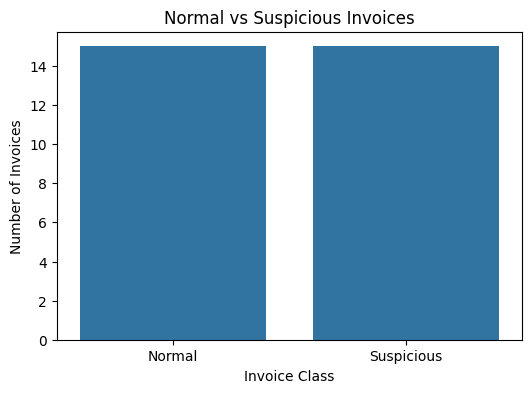

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x="label", data=df)

plt.title("Normal vs Suspicious Invoices")
plt.xlabel("Invoice Class")
plt.ylabel("Number of Invoices")
plt.xticks([0, 1], ["Normal", "Suspicious"])

plt.show()

In [9]:
df.describe()

,invoice_amount,gst_amount,quantity,unit_price,invoice_frequency,amount_deviation,gst_deviation,label
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,27388.333333,4929.900000,19.333333,1176.033333,6.100000,642.666667,64.266667,0.500000
std,27454.280752,4941.770535,16.599405,448.668335,3.907111,688.295913,68.829591,0.508548
min,1200.000000,216.000000,2.000000,500.000000,1.000000,50.000000,5.000000,0.000000
25%,5150.000000,927.000000,7.250000,712.500000,3.000000,122.500000,12.250000,0.000000
50%,16500.000000,2970.000000,12.500000,1350.000000,5.000000,325.000000,32.500000,0.500000
75%,44000.000000,7920.000000,28.750000,1500.000000,9.000000,937.500000,93.750000,1.000000
max,95000.000000,17100.000000,60.000000,2000.000000,15.000000,2500.000000,250.000000,1.000000


In [10]:
X = df.drop("label", axis=1)
y = df["label"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['invoice_amount', 'gst_amount', 'quantity', 'unit_price',
       'invoice_frequency', 'amount_deviation', 'gst_deviation'],
      dtype='object')

Target:
label


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [13]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 0 1 0]
